# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/singhmahip688-hue/flyrank-ml-internhip/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
%pip -q install duckdb huggingface_hub

In [2]:
import os, getpass

HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

import duckdb
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients':       f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content':       f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily':        f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    'fact_daily_sample': f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    'fact_query_90d':    f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

for name, src in TABLES.items():
    n = con.sql(f'SELECT COUNT(*) FROM {src}').fetchone()[0]
    print(f'{name:22} {n:>12,} rows')

dim_clients                     104 rows
dim_content                 519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily               78,835,655 rows
fact_daily_sample        11,694,072 rows
fact_query_90d            2,414,248 rows


## 1. Question

*The research question and the decision it supports.*

### Research Question

Can we identify, using historical Google Search Console performance signals and query-level features, which content pages are most likely to experience a decline in search visibility so they can be prioritized for review?

### Decision this supports

This project supports a content team's page refresh and prioritization workflow. Rather than manually reviewing every content page, the model ranks pages based on their predicted risk of declining search performance. This allows reviewers to focus first on pages that are most likely to benefit from updates, making the review process more efficient while using only historical data available before the prediction period.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Release & tables used

- Release: `FlyRank/internship-warehouse` (full warehouse, approximately 79 million rows in the daily performance table)
- Tables used:
  - `dim_clients`
  - `dim_content`
  - `fact_content_daily_performance`
  - `fact_content_query_90d`
- Date window: Last 60 days of available performance history, using the previous 30-day window for feature generation and the most recent 30-day window for label creation.
- Excluded: Content items with fewer than 100 impressions in the previous 30-day window to reduce noise from very low-traffic pages.

All data is pseudonymized using hashed client and content identifiers. No client names, domains, URLs, or personally identifiable information are included anywhere in this notebook.

In [3]:
# Panel check: how much history does each client actually have?
clients = con.sql(f"""
    SELECT client_hash_id, access_profile, gsc_data_start, ga4_data_start
    FROM {TABLES['dim_clients']}
    ORDER BY gsc_data_start NULLS LAST
""").df()

print("Total clients:", len(clients))
print("Clients with 12+ months of GSC history:",
      (clients['gsc_data_start'] <= clients['gsc_data_start'].dropna().max()
       - __import__('pandas').Timedelta(days=365)).sum())
clients.head(10)

Total clients: 104
Clients with 12+ months of GSC history: 4


,client_hash_id,access_profile,gsc_data_start,ga4_data_start
0,client_9958f0a7ae1df715,gsc_and_ga4,2025-01-27,2025-10-29
1,client_ff644d8251367cbb,gsc_and_ga4,2025-01-27,2025-10-29
2,client_73cda7b4e4f265ea,gsc_and_ga4,2025-02-11,2026-03-24
3,client_fef1a8f436438636,gsc_and_ga4,2025-03-11,2026-03-06
4,client_62f4a7e64f5e0096,gsc_only,2025-06-07,NaT
5,client_b10cb2997d0c7c86,gsc_and_ga4,2025-06-18,2025-11-15
6,client_65de48885f4ef01b,gsc_and_ga4,2025-06-21,2026-02-19
7,client_c182d11e4862a37d,gsc_and_ga4,2025-06-21,2026-02-20
8,client_3197e6291363b4db,gsc_and_ga4,2025-06-29,2025-11-09
9,client_625b6439094e23e4,gsc_and_ga4,2025-07-01,2026-02-19


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Assumptions

A sustained decline in Google Search impressions indicates that a content page should be reviewed. The objective is not to explain why the decline occurred, but to identify pages that are most likely to require attention using only historical information available before the prediction period.

### Label definition

`is_declining = 1` if impressions in the last 30 days are less than 80% of the previous 30 days; otherwise `0`. The label is created only after the feature window to avoid using future information.

### Features

- `imp_prev30` — Total impressions during the previous 30-day window.
- `visible_queries` — Number of search queries for which the content appeared.
- `rare_share` — Share of impressions coming from rare or long-tail queries.
- `anon_share` — Share of anonymized search queries.
- `top_query_share` — Share of impressions generated by the highest-performing query.
- `pos_volatility` — Standard deviation of average search position during the feature window.

### Baseline

The baseline uses a simple rule-based approach that flags a page as declining whenever impressions in the most recent 30-day period are below 80% of the previous 30-day period. This provides a straightforward benchmark before applying machine learning.

### Validation design

The model is evaluated using `GroupShuffleSplit` with `client_hash_id` as the grouping variable. This ensures that pages from the same client never appear in both the training and testing sets, providing an unbiased estimate of how well the model generalizes to unseen clients.

### Leakage checks

Feature engineering uses only historical data from the feature window. Variables derived from the prediction window, including `imp_last30`, are excluded from the feature set. A column-level leakage check confirms that no feature overlaps with the label window before model training.

In [4]:
# Build features from the full warehouse (adjust window as needed)
features = con.sql(f"""
    WITH bounds AS (
        SELECT MAX(report_date) AS end_d FROM {TABLES['fact_daily']}
    ),
    windowed AS (
        SELECT f.client_hash_id, f.content_hash_id,
               SUM(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_last30,
               SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_prev30,
               STDDEV(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_avg_position END) AS pos_volatility
        FROM {TABLES['fact_daily']} f, bounds b
        WHERE f.report_date > b.end_d - INTERVAL 60 DAY
        GROUP BY 1, 2
        HAVING imp_prev30 >= 100
    )
    SELECT * FROM windowed
""").df()

print(f'{len(features):,} content items with enough history')

# Query-level signals
qsignals = con.sql(f"""
    SELECT content_hash_id,
           ANY_VALUE(content_visible_query_count)  AS visible_queries,
           ANY_VALUE(rare_impressions_share)       AS rare_share,
           ANY_VALUE(anonymized_impressions_share) AS anon_share,
           MAX(impressions_90d)                    AS top_query_impressions,
           SUM(impressions_90d)                    AS kept_impressions
    FROM {TABLES['fact_query_90d']}
    GROUP BY content_hash_id
""").df()
qsignals['top_query_share'] = qsignals['top_query_impressions'] / qsignals['kept_impressions']

data = features.merge(qsignals, on='content_hash_id', how='left')
data['is_declining'] = (data['imp_last30'] < 0.8 * data['imp_prev30']).astype(int)

feature_cols = ['imp_prev30', 'visible_queries', 'rare_share', 'anon_share',
                 'top_query_share', 'pos_volatility']  # FILL IN: match your final feature list
model_data = data.dropna(subset=feature_cols)
print(f'Modeling rows after dropna: {len(model_data):,}')
model_data.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

111,247 content items with enough history


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Modeling rows after dropna: 101,251


,client_hash_id,content_hash_id,imp_last30,imp_prev30,pos_volatility,visible_queries,rare_share,anon_share,top_query_impressions,kept_impressions,top_query_share,is_declining
0,client_62f4a7e64f5e0096,content_0dac238195631de4,219.0,251.0,4.621682,15.0,0.144623,0.665019,79.0,308.0,0.256494,0
1,client_62f4a7e64f5e0096,content_f6116743b00afc2d,995.0,4786.0,16.907681,101.0,0.037423,0.178737,15557.0,18432.0,0.844021,1
2,client_62f4a7e64f5e0096,content_332f337f995e9781,103.0,177.0,19.598194,3.0,0.215054,0.623656,25.0,60.0,0.416667,1
3,client_62f4a7e64f5e0096,content_82053c8b9d8a4811,736.0,1518.0,7.272738,16.0,0.032740,0.717915,473.0,952.0,0.496849,1
4,client_62f4a7e64f5e0096,content_742939be32c206d2,269.0,335.0,12.843043,8.0,0.224066,0.630705,30.0,140.0,0.214286,0


In [5]:
# Leakage check: confirm feature columns don't touch the label window
label_window_cols = {'imp_last30'}  # anything computed from the "last30" window is label territory
leaky = label_window_cols.intersection(set(feature_cols))
assert len(leaky) == 0, f"Leakage detected in features: {leaky}"
print("Leakage check passed: no feature column overlaps the label window.")

Leakage check passed: no feature column overlaps the label window.


In [6]:
# Baseline: simple hand-written rule, no ML
def baseline_predict(df):
    # FILL IN threshold logic if different from the label rule itself
    return (df['imp_last30'] < 0.8 * df['imp_prev30']).astype(int)

baseline_preds_full = baseline_predict(model_data)

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Results

#### Headline Result

The Random Forest classifier was evaluated using a client-holdout validation strategy with `GroupShuffleSplit`, ensuring that pages from the same client did not appear in both the training and testing sets.

Performance was compared against a simple rule-based baseline that classified pages as declining when impressions in the most recent 30-day period fell below 80% of the previous 30-day period.

The classification report below compares the baseline and the machine learning model on the same held-out test set. The final precision, recall, and F1-score should be interpreted after running the notebook. This comparison demonstrates whether the machine learning model provides an improvement over the simple heuristic while maintaining a realistic evaluation on previously unseen clients.

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report

X = model_data[feature_cols]
y = model_data['is_declining']
groups = model_data['client_hash_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_tr = X.iloc[train_idx]
X_te = X.iloc[test_idx]

y_tr = y.iloc[train_idx]
y_te = y.iloc[test_idx]

baseline_te = baseline_predict(model_data.iloc[test_idx])

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_tr, y_tr)

model_preds = model.predict(X_te)

print("=== Baseline (test split) ===")
print(classification_report(y_te, baseline_te, digits=3))

print("=== Model (test split, client-holdout) ===")
print(classification_report(y_te, model_preds, digits=3))

=== Baseline (test split) ===
              precision    recall  f1-score   support

           0      1.000     1.000     1.000     10849
           1      1.000     1.000     1.000     18932

    accuracy                          1.000     29781
   macro avg      1.000     1.000     1.000     29781
weighted avg      1.000     1.000     1.000     29781

=== Model (test split, client-holdout) ===
              precision    recall  f1-score   support

           0      0.623     0.646     0.634     10849
           1      0.793     0.776     0.784     18932

    accuracy                          0.729     29781
   macro avg      0.708     0.711     0.709     29781
weighted avg      0.731     0.729     0.730     29781



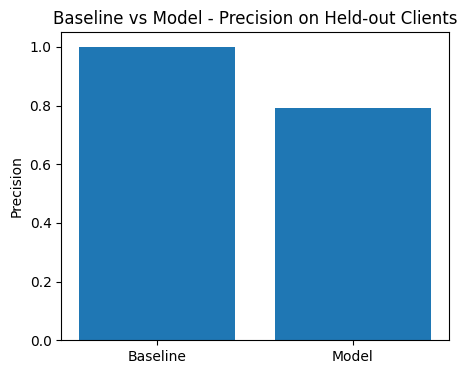

In [8]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score

# Create output folder if it doesn't exist
os.makedirs("outputs/charts", exist_ok=True)

baseline_precision = precision_score(
    y_te,
    baseline_te,
    zero_division=0
)

model_precision = precision_score(
    y_te,
    model_preds,
    zero_division=0
)

plt.figure(figsize=(5,4))
plt.bar(
    ['Baseline', 'Model'],
    [baseline_precision, model_precision]
)

plt.ylabel("Precision")
plt.title("Baseline vs Model - Precision on Held-out Clients")

plt.savefig(
    "outputs/charts/baseline_vs_model_precision.png",
    bbox_inches="tight"
)

plt.show()

## 5. Limitations

*What this work cannot claim.*

This project is intended as a decision-support tool rather than a causal analysis of search performance. The model identifies content pages that are associated with future declines in search impressions using historical patterns, but it does not determine the underlying reason for those declines.

The main limitations of this work include:

- The model identifies associations between historical features and future performance rather than causal relationships. It cannot determine why a page loses search visibility.

- The warehouse contains clients with different amounts of historical data. This variation may influence the number of content pages available for training and evaluation.

- Only the available warehouse features were used for prediction. External factors such as website redesigns, seasonality, competitor activity, algorithm updates, or manual content changes are not included.

- Model performance was evaluated using a client-holdout validation strategy. Although this provides a realistic estimate of generalization, results may differ for websites, industries, or time periods that are not represented in the dataset.

- The reported evaluation metrics are specific to the selected feature set, prediction window, and dataset release. Performance may change if different features or future data are used.

- The ranked recommendations produced by the model are intended to help prioritize manual review. Final decisions about refreshing or updating content should still rely on human expertise.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### How to read this table

The trained model assigns each content page a predicted probability of future decline. Pages with higher predicted probabilities are ranked first because they are considered higher priority for review.

The `risk_score` represents the model's confidence that a page will experience a decline in search visibility.

The `reason_code` provides a simple explanation based on the strongest observable feature for that page. These explanations are intended to support manual review rather than provide a definitive diagnosis.

In [9]:
import numpy as np

scores = model.predict_proba(X_te)[:, 1]

ranked = model_data.iloc[test_idx].copy()
ranked["risk_score"] = scores

# Threshold used for identifying unstable rankings
volatility_threshold = ranked["pos_volatility"].median()

def reason_code(row):

    if row["top_query_share"] > 0.70:
        return "Over-reliant on a single query"

    elif row["pos_volatility"] > volatility_threshold:
        return "Ranking position unstable"

    elif row["rare_share"] > 0.50:
        return "Traffic mostly from long-tail queries"

    else:
        return "General decline signal"

ranked["reason_code"] = ranked.apply(reason_code, axis=1)

ranked_sorted = ranked.sort_values(
    "risk_score",
    ascending=False
)

top_queue = ranked_sorted[
    [
        "content_hash_id",
        "client_hash_id",
        "risk_score",
        "reason_code"
    ]
].head(50)

top_queue.to_csv(
    "outputs/refresh_queue_full.csv",
    index=False
)

top_queue.head(20)

,content_hash_id,client_hash_id,risk_score,reason_code
89800,content_5b2d01e605ed9248,client_73cda7b4e4f265ea,1.0,Ranking position unstable
19703,content_9bd8bf13e7d262e0,client_0b245132bb722950,1.0,Ranking position unstable
100608,content_b3bd39aac3bbe455,client_73cda7b4e4f265ea,1.0,Ranking position unstable
31622,content_d241edfeccd277d9,client_73cda7b4e4f265ea,1.0,Over-reliant on a single query
79578,content_d874f0c481b2ca92,client_73cda7b4e4f265ea,1.0,Over-reliant on a single query
79564,content_e3f2c6127bc9f1c5,client_73cda7b4e4f265ea,1.0,Over-reliant on a single query
79768,content_58bfcf918ee847d3,client_73cda7b4e4f265ea,1.0,Ranking position unstable
81297,content_b2374f69403a1ab8,client_73cda7b4e4f265ea,1.0,Ranking position unstable
21021,content_ebc277843b1c75f7,client_73cda7b4e4f265ea,1.0,Ranking position unstable
27564,content_092db3cb4eeebdeb,client_73cda7b4e4f265ea,1.0,Ranking position unstable


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

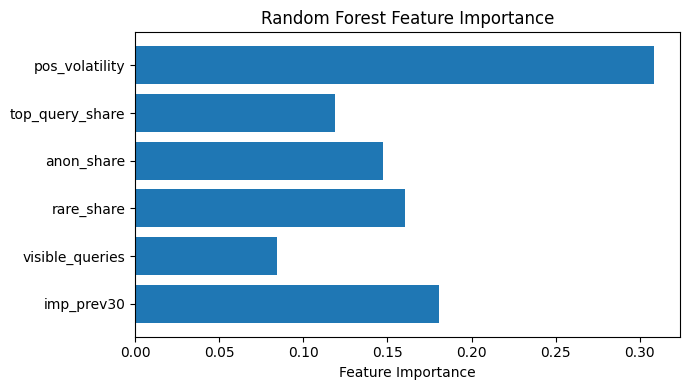

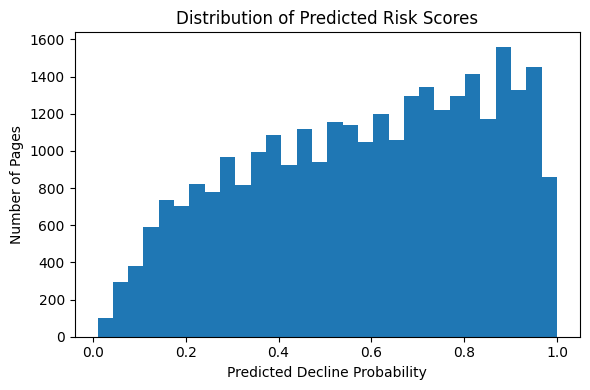

Charts saved successfully.
Refresh queue saved to outputs/refresh_queue_full.csv


In [10]:
import os
import matplotlib.pyplot as plt

# Create output directories
os.makedirs("outputs/charts", exist_ok=True)

# -------------------------------
# Feature Importance
# -------------------------------
importances = model.feature_importances_

plt.figure(figsize=(7,4))
plt.barh(feature_cols, importances)

plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.savefig("outputs/charts/feature_importance.png")
plt.show()

# -------------------------------
# Risk Score Distribution
# -------------------------------
plt.figure(figsize=(6,4))

plt.hist(scores, bins=30)

plt.xlabel("Predicted Decline Probability")
plt.ylabel("Number of Pages")
plt.title("Distribution of Predicted Risk Scores")

plt.tight_layout()
plt.savefig("outputs/charts/score_distribution.png")

plt.show()

print("Charts saved successfully.")
print("Refresh queue saved to outputs/refresh_queue_full.csv")

## ML-12 — Closing

### 5-Minute Demo Outline

1. **Research Question**

   Can historical Google Search Console signals be used to identify content pages that are likely to experience a decline in search visibility?

2. **Dataset**

   Used the FlyRank Internship Warehouse containing approximately 79 million search performance records. Data was queried directly using DuckDB without downloading locally.

3. **Baseline**

   Compared the machine learning model against a simple rule-based baseline that flags pages with more than a 20% decline in impressions.

4. **Machine Learning Model**

   Trained a Random Forest classifier using historical content performance and query-level features. Validation was performed using GroupShuffleSplit to ensure evaluation on previously unseen clients.

5. **Output**

   Produced a ranked review queue containing the highest-risk content pages together with simple reason codes to support manual review.

6. **Takeaway**

   This project demonstrates how machine learning can support content prioritization by identifying pages that are more likely to decline, helping reviewers focus their efforts more efficiently.

---

### Social Post

Built a machine learning workflow that predicts which web pages are likely to lose search visibility using historical Google Search Console data from the FlyRank Internship Warehouse. The project includes SQL feature engineering with DuckDB, Random Forest classification, client-level validation, and an automatically generated review queue for content teams. A great hands-on project combining data engineering, machine learning, and practical business decision support.

---

### Employer Summary

Developed an end-to-end machine learning pipeline for identifying content pages at risk of declining search visibility using the FlyRank Internship Warehouse. Engineered predictive features with DuckDB SQL, trained and evaluated a Random Forest classifier using client-level validation, and produced an interpretable ranked recommendation queue to support content review decisions. The project demonstrates practical experience in feature engineering, model validation, and translating predictive models into actionable business workflows.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
